# ЛР 1.1 — Лагранж (классика и барицентрический), разделённые разности, Ньютон

**Вариант 31:**  
- $f(x) = (x - 0{,}5)^3 \ln x$, $x \in [0{,}3;\, 0{,}8]$  
- $g(x) = e^{\cos(3x)}$, $x \in [0;\, \pi]$

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.unicode_minus"] = False

## Функции

Интервалы: $[0{,}3,\, 0{,}8]$ и $[0,\, \pi]$ (в коде — обычная точка в дробях).

In [29]:
def f(x):
    """f(x) = (x - 0.5)^3 * ln(x), область x > 0."""
    x = np.asarray(x, dtype=float)
    return (x - 0.5) ** 3 * np.log(x)


def g(x):
    """g(x) = exp(cos(3x))."""
    return np.exp(np.cos(3.0 * np.asarray(x, dtype=float)))


a_f, b_f = 0.3, 0.8
a_g, b_g = 0.0, np.pi

## Узлы интерполяции

Равномерная сетка, случайные (с фиксированным seed), узлы Чебышёва на $[a,b]$.

In [30]:
def nodes_uniform(a, b, n):
    return np.linspace(a, b, n)


def nodes_random(a, b, n, seed=42):
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(a, b, n))
    return x


def nodes_chebyshev(a, b, n):
    """n узлов на [a,b], через cos((2k-1)π/(2n))."""
    k = np.arange(1, n + 1)
    t = np.cos((2 * k - 1) / (2 * n) * np.pi)
    return 0.5 * (a + b) + 0.5 * (b - a) * t

## Многочлен Лагранжа — классический вид

$$
L(x) = \sum_{i=0}^{n-1} y_i \prod_{j \neq i} \frac{x - x_j}{x_i - x_j}
$$

In [31]:
def lagrange_classic(x_nodes, y_nodes, x_eval):
    x_eval = np.asarray(np.atleast_1d(x_eval), dtype=float)
    n = len(x_nodes)
    y = np.zeros_like(x_eval, dtype=float)
    for i in range(n):
        Li = np.ones_like(x_eval, dtype=float)
        for j in range(n):
            if i != j:
                Li *= (x_eval - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        y += y_nodes[i] * Li
    return y

## Барицентрическая форма Лагранжа

Веса $w_i = 1 / \prod_{j \neq i}(x_i - x_j)$, затем
$$L(x) = \frac{\sum_i w_i y_i / (x - x_i)}{\sum_i w_i / (x - x_i)}$$
при $x \notin \{x_i\}$; в узле — $y_i$.

In [32]:
def barycentric_weights(x_nodes):
    n = len(x_nodes)
    w = np.ones(n, dtype=float)
    for i in range(n):
        for j in range(n):
            if i != j:
                w[i] /= x_nodes[i] - x_nodes[j]
    return w


def lagrange_barycentric(x_nodes, y_nodes, x_eval):
    x_eval = np.asarray(np.atleast_1d(x_eval), dtype=float)
    w = barycentric_weights(x_nodes)
    y = np.zeros_like(x_eval, dtype=float)
    for k, x in enumerate(x_eval):
        hit = np.where(np.isclose(x, x_nodes, rtol=0.0, atol=1e-14))[0]
        if len(hit):
            y[k] = y_nodes[hit[0]]
        else:
            t = w / (x - x_nodes)
            y[k] = np.dot(t, y_nodes) / np.sum(t)
    return y

## Разделённые разности и многочлен Ньютона

Коэффициенты $c_k = f[x_0,\ldots,x_k]$, представление
$$N(x) = c_0 + c_1(x-x_0) + c_2(x-x_0)(x-x_1) + \cdots$$

In [33]:
def divided_differences_table(x_nodes, y_nodes):
    """Возвращает массив коэффициентов c[k] = f[x0,...,xk] (диагональ таблицы)."""
    n = len(x_nodes)
    dd = y_nodes.astype(float).copy()
    coef = np.zeros(n, dtype=float)
    coef[0] = dd[0]
    for j in range(1, n):
        dd[0 : n - j] = (dd[1 : n - j + 1] - dd[0 : n - j]) / (
            x_nodes[j:n] - x_nodes[0 : n - j]
        )
        coef[j] = dd[0]
    return coef


def newton_eval(x_nodes, coef, x_eval):
    x_eval = np.asarray(np.atleast_1d(x_eval), dtype=float)
    n = len(coef)
    y = np.full_like(x_eval, coef[-1], dtype=float)
    for k in range(n - 2, -1, -1):
        y = y * (x_eval - x_nodes[k]) + coef[k]
    return y

## Проверка: три формы задают один многочлен

На равномерных узлах для $f$ сравниваем максимальное расхождение между реализациями.

In [34]:
def check_three_methods(func, a, b, n_nodes=10):
    xn = nodes_uniform(a, b, n_nodes)
    yn = func(xn)
    xe = np.linspace(a, b, 300)
    y_l = lagrange_classic(xn, yn, xe)
    y_b = lagrange_barycentric(xn, yn, xe)
    c = divided_differences_table(xn, yn)
    y_n = newton_eval(xn, c, xe)
    print(
        "max|L_classic - L_bary|:", np.max(np.abs(y_l - y_b)),
    )
    print(
        "max|L_classic - Newton|:", np.max(np.abs(y_l - y_n)),
    )
    print("коэффициенты Ньютона (разделённые разности f):", c)
    return xn, yn, xe, y_l, y_b, y_n, c


print("f")
xn_f, yn_f, xe_f, y_l_f, y_b_f, y_n_f, c_f = check_three_methods(f, a_f, b_f, 10)
print("\ng")
xn_g, yn_g, xe_g, y_l_g, y_b_g, y_n_g, c_g = check_three_methods(g, a_g, b_g, 10)

f
max|L_classic - L_bary|: 1.1275702593849246e-17
max|L_classic - Newton|: 1.734723475976807e-17
коэффициенты Ньютона (разделённые разности f): [ 0.00963178 -0.11727677  0.6517693  -2.06766554  3.4637771  -3.66743554
  4.35798294 -5.18380897  5.98134017 -6.61797216]

g
max|L_classic - L_bary|: 3.9968028886505635e-15
max|L_classic - Newton|: 4.729550084903167e-14
коэффициенты Ньютона (разделённые разности f): [ 2.71828183 -3.06406529  0.11231279  3.04146766 -3.09386266  2.82182086
 -2.69464043  1.56372949 -0.04866071 -0.77252574]


## Графики для $f(x)$

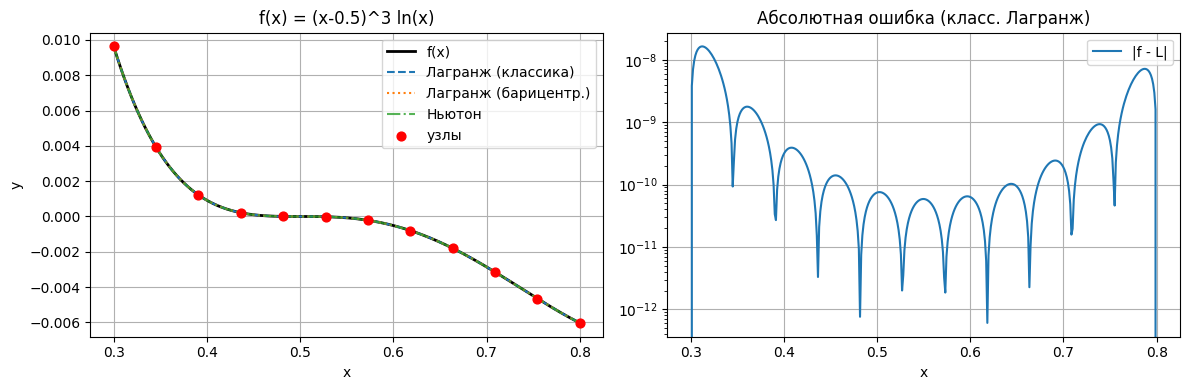

max |f - L| на сетке: 1.639520548577661e-08
mean |f - L|: 1.3985766287108473e-09


In [35]:
n_f = 12
x_nodes_f = nodes_uniform(a_f, b_f, n_f)
y_nodes_f = f(x_nodes_f)
coef_f = divided_differences_table(x_nodes_f, y_nodes_f)

x_plot_f = np.linspace(a_f, b_f, 400)
y_true_f = f(x_plot_f)
y_L_f = lagrange_classic(x_nodes_f, y_nodes_f, x_plot_f)
y_B_f = lagrange_barycentric(x_nodes_f, y_nodes_f, x_plot_f)
y_N_f = newton_eval(x_nodes_f, coef_f, x_plot_f)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x_plot_f, y_true_f, "k-", lw=2, label="f(x)")
ax[0].plot(x_plot_f, y_L_f, "--", label="Лагранж (классика)")
ax[0].plot(x_plot_f, y_B_f, ":", label="Лагранж (барицентр.)")
ax[0].plot(x_plot_f, y_N_f, "-.", alpha=0.8, label="Ньютон")
ax[0].scatter(x_nodes_f, y_nodes_f, color="red", s=40, zorder=5, label="узлы")
ax[0].set_title("$f(x) = (x-0.5)^3 \\ln x$")
ax[0].legend()
ax[0].set_xlabel("Аргумент $x$")
ax[0].set_ylabel("Значение $y$")

err_f = np.abs(y_true_f - y_L_f)
ax[1].semilogy(x_plot_f, err_f, label="$|f - L|$")
ax[1].set_title("Абсолютная погрешность (классический Лагранж)")
ax[1].set_xlabel("Аргумент $x$")
ax[1].set_ylabel("Погрешность")
ax[1].legend()
plt.tight_layout()
plt.show()

print("макс. |f - L| на сетке:", float(np.max(err_f)))
print("средняя |f - L|:", float(np.mean(err_f)))

## Графики для $g(x) = e^{\cos(3x)}$

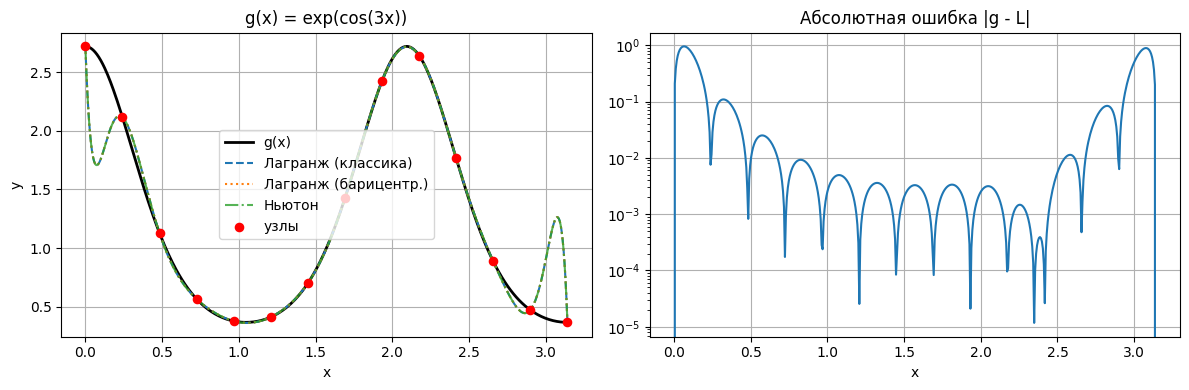

max |g - L|: 0.9517704847463024
mean |g - L|: 0.09001646727645582


In [36]:
n_g = 14
x_nodes_g = nodes_uniform(a_g, b_g, n_g)
y_nodes_g = g(x_nodes_g)
coef_g = divided_differences_table(x_nodes_g, y_nodes_g)

x_plot_g = np.linspace(a_g, b_g, 500)
y_true_g = g(x_plot_g)
y_L_g = lagrange_classic(x_nodes_g, y_nodes_g, x_plot_g)
y_B_g = lagrange_barycentric(x_nodes_g, y_nodes_g, x_plot_g)
y_N_g = newton_eval(x_nodes_g, coef_g, x_plot_g)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x_plot_g, y_true_g, "k-", lw=2, label="g(x)")
ax[0].plot(x_plot_g, y_L_g, "--", label="Лагранж (классика)")
ax[0].plot(x_plot_g, y_B_g, ":", label="Лагранж (барицентр.)")
ax[0].plot(x_plot_g, y_N_g, "-.", alpha=0.8, label="Ньютон")
ax[0].scatter(x_nodes_g, y_nodes_g, color="red", s=35, zorder=5, label="узлы")
ax[0].set_title("$g(x) = \\exp(\\cos 3x)$")
ax[0].legend()
ax[0].set_xlabel("Аргумент $x$")
ax[0].set_ylabel("Значение $y$")

err_g = np.abs(y_true_g - y_L_g)
ax[1].semilogy(x_plot_g, err_g)
ax[1].set_title("Абсолютная погрешность $|g - L|$")
ax[1].set_xlabel("Аргумент $x$")
ax[1].set_ylabel("Погрешность")
plt.tight_layout()
plt.show()

print("макс. |g - L|:", float(np.max(err_g)))
print("средняя |g - L|:", float(np.mean(err_g)))

## Сравнение типов узлов для той же степени

Для отчёта: случайные / равномерные / Чебышёв — таблица ошибок.

In [37]:
def errors_on_grid(func, a, b, x_nodes, x_dense):
    y_nodes = func(x_nodes)
    y_true = func(x_dense)
    y_L = lagrange_classic(x_nodes, y_nodes, x_dense)
    e = np.abs(y_true - y_L)
    return float(np.max(e)), float(np.mean(e))


def compare_nodes(func, a, b, n=12, m=400):
    x_dense = np.linspace(a, b, m)
    rows = []
    for name, xn in [
        ("равномерные", nodes_uniform(a, b, n)),
        ("случайные", nodes_random(a, b, n, seed=42)),
        ("Чебышёв", nodes_chebyshev(a, b, n)),
    ]:
        mx, mn = errors_on_grid(func, a, b, xn, x_dense)
        rows.append((name, mx, mn))
    return rows


print("f(x), n=12")
for r in compare_nodes(f, a_f, b_f, n=12):
    print(f"  {r[0]:12} макс_ош={r[1]:.3e}  сред_ош={r[2]:.3e}")

print("\ng(x), n=12")
for r in compare_nodes(g, a_g, b_g, n=12):
    print(f"  {r[0]:12} макс_ош={r[1]:.3e}  сред_ош={r[2]:.3e}")

f(x), n=12
  равномерные  max_err=1.640e-08  mean_err=1.399e-09
  случайные    max_err=8.802e-07  mean_err=2.291e-08
  Чебышёв      max_err=1.605e-09  mean_err=6.372e-10

g(x), n=12
  равномерные  max_err=1.538e+00  mean_err=1.483e-01
  случайные    max_err=2.471e+02  mean_err=6.810e+00
  Чебышёв      max_err=8.355e-02  mean_err=2.346e-02


## Анализ результатов

- **Практическая** погрешность: $\max_x |f(x) - P(x)|$ (и средняя) на плотной сетке.
- **Теоретическая** оценка остатка: $|R(x)| \le \dfrac{M_{m}}{m!}\,\max_x\big|\prod_j (x-x_j)\big|$, где $m$ — **число узлов**, $M_m = \max_{t\in[a,b]}|f^{(m)}(t)|$ (ниже $M_m$ для наших $f$ и $g$ считаем через **SymPy**: символьная производная + сетка на $[a,b]$).
- Для **одних и тех же узлов** классический Лагранж, барицентрическая форма и Ньютон задают **один многочлен** — практические ошибки (iii) и (iv) совпадают с (ii) с точностью до округления.

In [38]:
from time import perf_counter
from math import factorial

try:
    import sympy as sp

    _sx = sp.symbols("_sx", real=True)
    _f_sym = (_sx - sp.Rational(1, 2)) ** 3 * sp.log(_sx)
    _g_sym = sp.exp(sp.cos(3 * _sx))

    def max_abs_derivative_sym(sym_expr, a, b, order, n_t=500):
        if order <= 0:
            return 0.0
        dexpr = sp.diff(sym_expr, _sx, order)
        fn = sp.lambdify(_sx, sp.Abs(dexpr), modules=["numpy"])
        ts = np.linspace(float(a), float(b), n_t)
        vals = np.abs(fn(ts))
        vals = np.asarray(vals, dtype=float).ravel()
        vals = vals[np.isfinite(vals)]
        return float(np.max(vals)) if len(vals) else np.nan

    HAS_SYMPY = True
except ImportError:
    HAS_SYMPY = False
    print("sympy не найден: теоретическая оценка M_m будет пропущена (pip install sympy).")


def omega_product(x_nodes, x_dense):
    w = np.ones_like(x_dense, dtype=float)
    for xj in x_nodes:
        w *= np.abs(x_dense - xj)
    return w


def practical_errors(func, x_nodes, x_dense):
    y_nodes = func(x_nodes)
    y_true = func(x_dense)
    y_l = lagrange_classic(x_nodes, y_nodes, x_dense)
    y_b = lagrange_barycentric(x_nodes, y_nodes, x_dense)
    c = divided_differences_table(x_nodes, y_nodes)
    y_n = newton_eval(x_nodes, c, x_dense)
    e_l = np.abs(y_true - y_l)
    e_b = np.abs(y_true - y_b)
    e_n = np.abs(y_true - y_n)
    return {
        "max_L": float(np.max(e_l)),
        "mean_L": float(np.mean(e_l)),
        "max_bary": float(np.max(e_b)),
        "max_newton": float(np.max(e_n)),
    }


def theoretical_bound(func, a, b, x_nodes, x_dense):
    m = len(x_nodes)
    om = omega_product(x_nodes, x_dense)
    max_om = float(np.max(om))
    if not HAS_SYMPY:
        return np.nan, max_om
    sym = _f_sym if func is f else _g_sym if func is g else None
    if sym is None:
        return np.nan, max_om
    M = max_abs_derivative_sym(sym, a, b, m)
    if not np.isfinite(M) or M <= 0:
        return np.nan, max_om
    return M / factorial(m) * max_om, max_om


def analysis_table(func, a, b, n_nodes=10, m_dense=500):
    x_dense = np.linspace(a, b, m_dense)
    rows = []
    setups = [
                ("i) Лагранж, случайные узлы", nodes_random(a, b, n_nodes, seed=42)),
        ("ii) Лагранж, равномерные узлы", nodes_uniform(a, b, n_nodes)),
    ]
    for label, xn in setups:
        pr = practical_errors(func, xn, x_dense)
        th, _ = theoretical_bound(func, a, b, xn, x_dense)
        rows.append(
            {
                "случай": label,
                "практ_макс": pr["max_L"],
                "теор_оценка": th,
            }
        )
    x_uni = nodes_uniform(a, b, n_nodes)
    pr = practical_errors(func, x_uni, x_dense)
    th, _ = theoretical_bound(func, a, b, x_uni, x_dense)
    rows.append(
        {
                        "случай": "iii) Лагранж, барицентрический (равномерные узлы)",
            "практ_макс": pr["max_bary"],
            "теор_оценка": th,
        }
    )
    rows.append(
        {
                        "случай": "iv) Ньютон, разделённые разности (равномерные узлы)",
            "практ_макс": pr["max_newton"],
            "теор_оценка": th,
        }
    )
    import pandas as pd

    return pd.DataFrame(rows)


print("Таблица для f(x)")
print(analysis_table(f, a_f, b_f, n_nodes=10).to_string(index=False))
print("Таблица для g(x)")
print(analysis_table(g, a_g, b_g, n_nodes=10).to_string(index=False))

Table for f(x)
                                          case  practical_max  theoretical_bound
                     i) Lagrange, random nodes   4.786072e-06           0.001644
                   ii) Lagrange, uniform nodes   2.005919e-07           0.000031
     iii) Lagrange barycentric (uniform nodes)   2.005919e-07           0.000031
iv) Newton divided differences (uniform nodes)   2.005919e-07           0.000031
Table for g(x)
                                          case  practical_max  theoretical_bound
                     i) Lagrange, random nodes      75.073692       17519.628614
                   ii) Lagrange, uniform nodes       1.390798         334.099598
     iii) Lagrange barycentric (uniform nodes)       1.390798         334.099598
iv) Newton divided differences (uniform nodes)       1.390798         334.099598


### Минимизация ошибки для $f$: многочлены Лагранжа степеней 1, 2, 3

Степень $\le d$ при **$d+1$** равномерных узлах на $[a_f,b_f]$.

deg <= 1 (2 nodes): max_err=5.585e-03, mean_err=2.168e-03
deg <= 2 (3 nodes): max_err=4.459e-03, mean_err=1.820e-03
deg <= 3 (4 nodes): max_err=1.617e-03, mean_err=7.402e-04


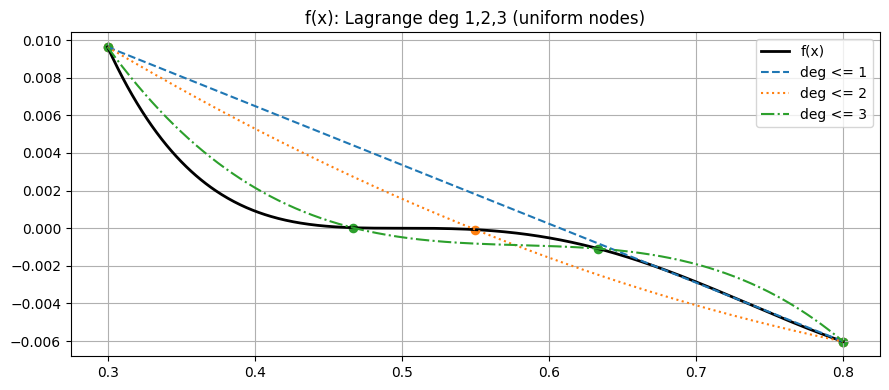

In [39]:
x_dense_f = np.linspace(a_f, b_f, 600)
y_true_fd = f(x_dense_f)
for d in [1, 2, 3]:
    nn = d + 1
    xn = nodes_uniform(a_f, b_f, nn)
    yn = f(xn)
    yp = lagrange_classic(xn, yn, x_dense_f)
    err = np.abs(y_true_fd - yp)
    print(
        f"степень ≤ {d} ({nn} узлов): макс_ош={np.max(err):.3e}, сред_ош={np.mean(err):.3e}"
    )

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_dense_f, y_true_fd, "k-", lw=2, label="f(x)")
for d, sty in zip([1, 2, 3], ["--", ":", "-."]):
    nn = d + 1
    xn = nodes_uniform(a_f, b_f, nn)
    yn = f(xn)
    yp = lagrange_classic(xn, yn, x_dense_f)
    ax.plot(x_dense_f, yp, sty, label=f"степень ≤ {d}")
    ax.scatter(xn, yn, s=35)
ax.legend()
ax.set_title("$f(x)$: Лагранж степеней 1, 2 и 3 (равномерные узлы)")
plt.tight_layout()
plt.show()

### Влияние числа узлов $n$ на точность

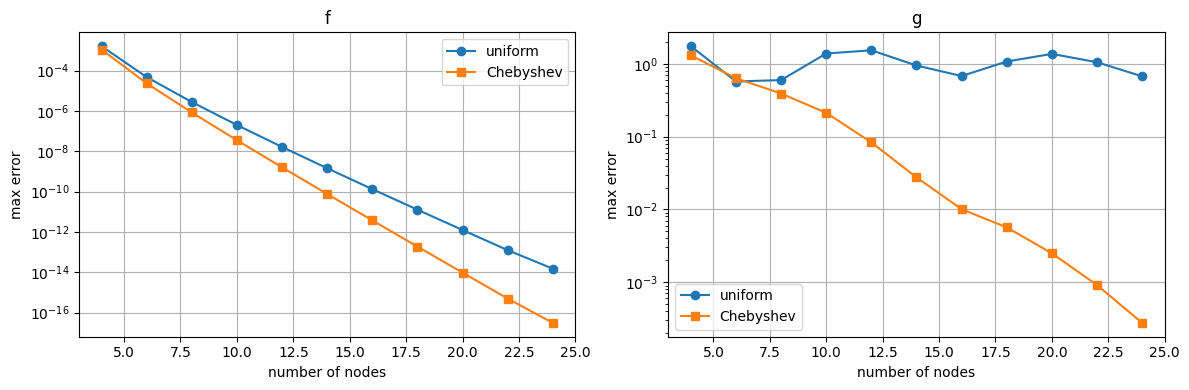

In [40]:
def max_error_vs_n(func, a, b, n_list, node_builder, m_dense=500):
    x_dense = np.linspace(a, b, m_dense)
    y_true = func(x_dense)
    out = []
    for n in n_list:
        xn = node_builder(a, b, n)
        yn = func(xn)
        yp = lagrange_classic(xn, yn, x_dense)
        out.append((n, float(np.max(np.abs(y_true - yp)))))
    return out


ns = list(range(4, 25, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for func, a, b, title in [
    (f, a_f, b_f, "f"),
    (g, a_g, b_g, "g"),
]:
    i = 0 if title == "f" else 1
    eu = max_error_vs_n(func, a, b, ns, nodes_uniform)
    ec = max_error_vs_n(func, a, b, ns, nodes_chebyshev)
    ax[i].semilogy([t[0] for t in eu], [t[1] for t in eu], "o-", label="равномерные узлы")
    ax[i].semilogy([t[0] for t in ec], [t[1] for t in ec], "s-", label="узлы Чебышёва")
    ax[i].set_xlabel("Число узлов")
    ax[i].set_ylabel("Макс. погрешность")
    ax[i].set_title("функция " + title)
    ax[i].legend()
plt.tight_layout()
plt.show()

### 6.3 Сравнение узлов: случайные / равномерные / Чебышёв

In [41]:
import pandas as pd


def compare_three_node_types(func, a, b, n=12, m=500):
    x_dense = np.linspace(a, b, m)
    rows = []
    for name, gen in [
        ("random", lambda: nodes_random(a, b, n, seed=42)),
                ("равномерные", lambda: nodes_uniform(a, b, n)),
        ("Чебышёв", lambda: nodes_chebyshev(a, b, n)),
    ]:
        xn = gen()
        pr = practical_errors(func, xn, x_dense)
        rows.append(
            {"узлы": name, "макс_ошибка_L": pr["max_L"], "сред_ошибка": pr["mean_L"]}
        )
    return pd.DataFrame(rows)


print("f(x), n=12")
print(compare_three_node_types(f, a_f, b_f).to_string(index=False))
print("g(x), n=12")
print(compare_three_node_types(g, a_g, b_g).to_string(index=False))

f, n=12
    nodes  max_err (L)     mean_err
   random 8.801668e-07 2.268982e-08
  uniform 1.639141e-08 1.399722e-09
Chebyshev 1.604592e-09 6.365981e-10
g, n=12
    nodes  max_err (L)  mean_err
   random   247.128666  6.749436
  uniform     1.539648  0.148425
Chebyshev     0.083544  0.023444


### 6.4 Феномен Рунге для $g(x)$: равномерные vs Чебышёв при большом $n$

Для $g(x)=e^{\cos 3x}$ эффект обычно слабее классической функции Рунге; сравниваем ошибки и поведение у границ отрезка.

uniform: max_err=1.056e+00
Chebyshev: max_err=9.127e-04


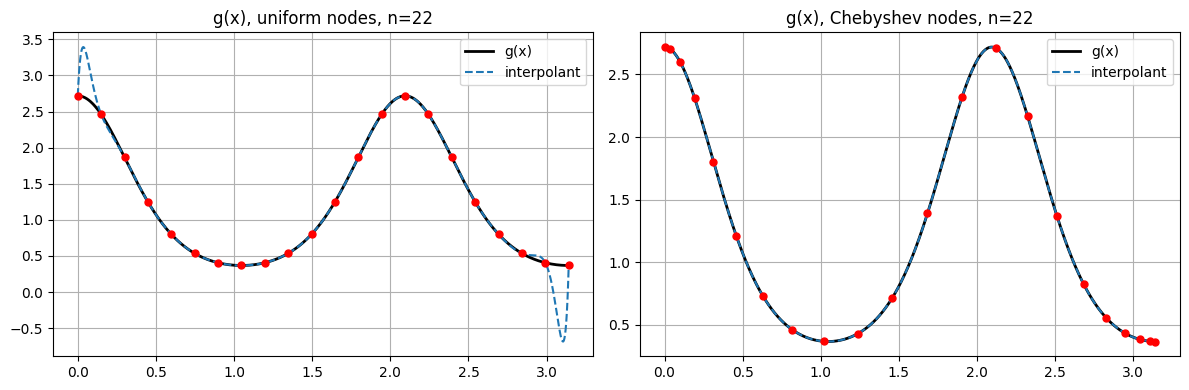

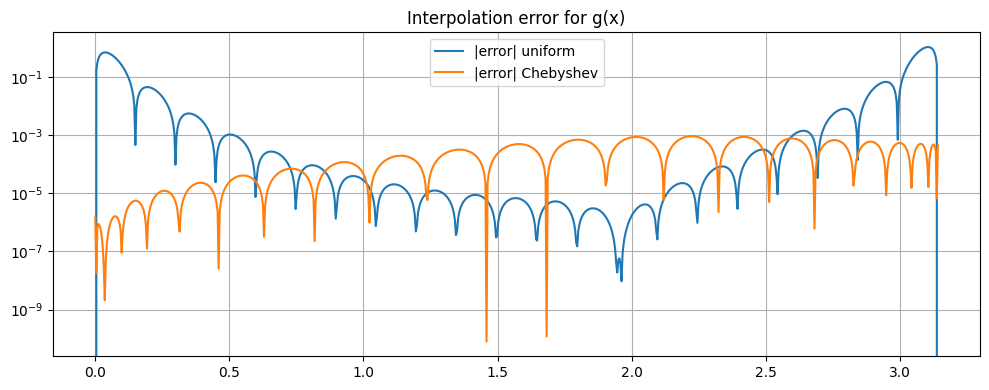

In [42]:
n_big = 22
x_dense = np.linspace(a_g, b_g, 800)
yg = g(x_dense)

for kind, xn in [
    ("равномерные", nodes_uniform(a_g, b_g, n_big)),
    ("Чебышёв", nodes_chebyshev(a_g, b_g, n_big)),
]:
    yn = g(xn)
    yp = lagrange_barycentric(xn, yn, x_dense)
    err = np.abs(yg - yp)
    print(f"{kind}: макс. погрешность = {np.max(err):.3e}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for j, (kind, xn) in enumerate(
    [
        ("равномерные", nodes_uniform(a_g, b_g, n_big)),
        ("Чебышёв", nodes_chebyshev(a_g, b_g, n_big)),
    ]
):
    yn = g(xn)
    yp = lagrange_barycentric(xn, yn, x_dense)
    ax[j].plot(x_dense, yg, "k-", lw=2, label="g(x)")
    ax[j].plot(x_dense, yp, "--", label="интерполянт")
    ax[j].scatter(xn, yn, c="red", s=25, zorder=5)
    ax[j].set_title(f"$g(x)$, узлы: {kind}, $n={n_big}$")
    ax[j].set_xlabel("Аргумент $x$")
    ax[j].set_ylabel("Значение $y$")
    ax[j].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for kind, xn in [
    ("равномерные", nodes_uniform(a_g, b_g, n_big)),
    ("Чебышёв", nodes_chebyshev(a_g, b_g, n_big)),
]:
    yn = g(xn)
    yp = lagrange_barycentric(xn, yn, x_dense)
    ax.semilogy(x_dense, np.abs(yg - yp), label=f"|погрешность|, {kind}")
ax.set_title("Погрешность интерполяции $g(x)$")
ax.set_xlabel("Аргумент $x$")
ax.set_ylabel("Погрешность")
ax.legend()
plt.tight_layout()
plt.show()

### 6.5 Время выполнения vs число узлов

 n  Lagrange classic  Lagrange bary   Newton
 6          0.000087       0.008223 0.000028
10          0.000218       0.006716 0.000043
15          0.000500       0.006947 0.000138
20          0.001197       0.008071 0.000099
30          0.002093       0.006771 0.000146
40          0.004538       0.006676 0.000166


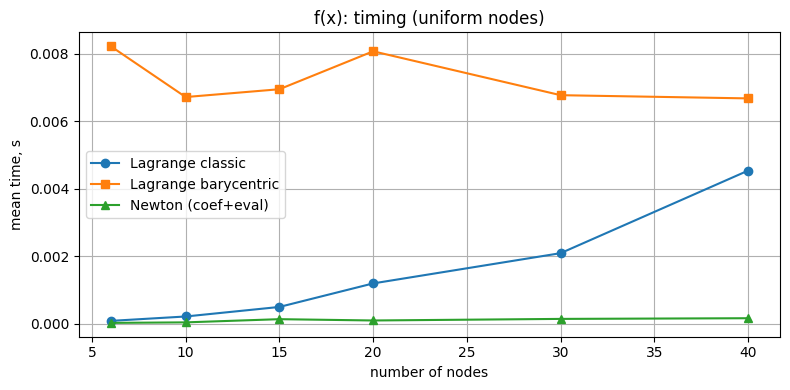

In [43]:
def bench_methods(n_nodes, m_eval=300, repeats=5):
    xn = nodes_uniform(a_f, b_f, n_nodes)
    yn = f(xn)
    xe = np.linspace(a_f, b_f, m_eval)

    def mean_time(fn):
        t0 = perf_counter()
        for _ in range(repeats):
            fn()
        return (perf_counter() - t0) / repeats

    t_l = mean_time(lambda: lagrange_classic(xn, yn, xe))
    t_b = mean_time(lambda: lagrange_barycentric(xn, yn, xe))

    def newton_once():
        c = divided_differences_table(xn, yn)
        newton_eval(xn, c, xe)

    t_n = mean_time(newton_once)
    return t_l, t_b, t_n


rows = []
for n in [6, 10, 15, 20, 30, 40]:
    tl, tb, tn = bench_methods(n)
    rows.append({"n": n, "класс. Лагранж": tl, "барицентр. Лагранж": tb, "Ньютон": tn})

df_time = pd.DataFrame(rows)
print(df_time.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(df_time["n"], df_time["класс. Лагранж"], "o-", label="классический Лагранж")
plt.plot(df_time["n"], df_time["барицентр. Лагранж"], "s-", label="барицентрический Лагранж")
plt.plot(df_time["n"], df_time["Ньютон"], "^-", label="Ньютон (коэффициенты + значения)")
plt.xlabel("Число узлов")
plt.ylabel("Среднее время, с")
plt.title("$f(x)$: время выполнения (равномерные узлы)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()